In [38]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd
from matplotlib.animation import FuncAnimation
from IPython.display import HTML, display

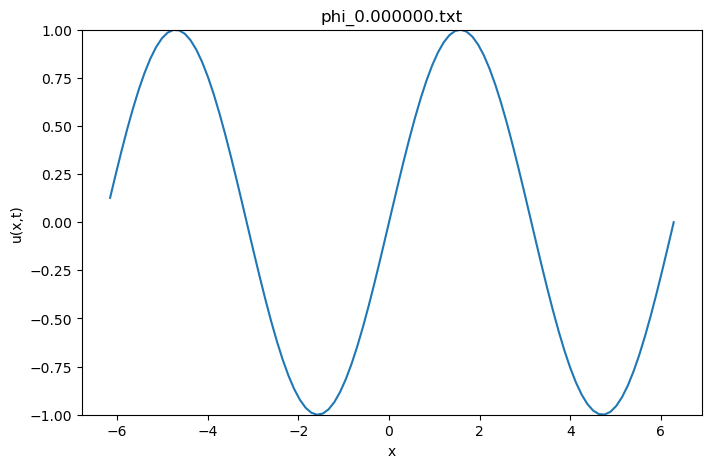

In [39]:
files = sorted([f for f in Path("../results/HE").iterdir() if f.is_file()])

fig, ax = plt.subplots(figsize=(8, 5))

def update(i):
    ax.clear()
    file = files[i]
    ax.set_title(file.name)

    ext = file.suffix.lower()
    if ext in {".png", ".jpg", ".jpeg", ".bmp", ".gif"}:
        img = plt.imread(file)
        ax.imshow(img)
        ax.axis("off")
    else:
        df = pd.read_csv(file)
        num = df.select_dtypes(include="number")
        if num.shape[1] >= 2:
            ax.plot(num.iloc[:, 0], num.iloc[:, 1])
            ax.set_xlabel("x")
            ax.set_ylabel("u(x,t)")
            ax.set_ylim(-1,1)
        elif num.shape[1] == 1:
            ax.plot(num.iloc[:, 0])
            ax.set_ylabel(num.columns[0])
        else:
            ax.text(0.5, 0.5, "No numeric data found", ha="center", va="center")

anim = FuncAnimation(fig, update, frames=len(files), interval=1000, repeat=True)
display(HTML(anim.to_jshtml()))